# Bertus Delivery Performance Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

## Load & prepare data

In [2]:
df = pd.read_csv('bertus_shipments_raw.csv')

df['order_date'] = pd.to_datetime(df['order_date'])
df['promised_delivery_date'] = pd.to_datetime(df['promised_delivery_date'])
df['actual_delivery_date'] = pd.to_datetime(df['actual_delivery_date'])

df['delay_days'] = (df['actual_delivery_date'] - df['promised_delivery_date']).dt.days
df['on_time'] = df['delay_days'] <= 0
df['order_month'] = df['order_date'].dt.strftime('%b-%y')

df.head()

,shipment_id,order_date,customer_type,destination_country,product_category,carrier,promised_delivery_date,actual_delivery_date,delay_reason,order_value_eur,delay_days,on_time,order_month
0,SH0001,2026-04-29,Independent Store,Germany,Vinyl,UPS,2026-05-02,2026-05-02,NaN,223,0,True,Apr-26
1,SH0002,2026-07-18,Online Retailer,United Kingdom,Vinyl,UPS,2026-07-21,2026-07-25,Customs hold,452,4,False,Jul-26
2,SH0003,2026-07-17,Independent Store,Germany,Merchandise,DPD,2026-07-23,2026-07-22,NaN,614,-1,True,Jul-26
3,SH0004,2026-05-10,Independent Store,Netherlands,Merchandise,PostNL,2026-05-16,2026-05-15,NaN,780,-1,True,May-26
4,SH0005,2026-06-28,Online Retailer,Netherlands,Merchandise,PostNL,2026-07-05,2026-07-04,NaN,1175,-1,True,Jun-26


## Headline numbers

In [3]:
total_shipments = len(df)
on_time_rate = df['on_time'].mean() * 100
avg_delay_late = df[df['delay_days'] > 0]['delay_days'].mean()
total_value = df['order_value_eur'].sum()

print(f"Total shipments:        {total_shipments}")
print(f"On-time rate:           {on_time_rate:.1f}%")
print(f"Avg delay (late only):  {avg_delay_late:.1f} days")
print(f"Total order value:      €{total_value:,.0f}")

Total shipments:        140
On-time rate:           73.6%
Avg delay (late only):  4.6 days
Total order value:      €126,797


## Delay reasons

In [4]:
delayed = df[df['delay_reason'].notna()]
reason_counts = delayed.groupby('delay_reason').size()
reason_pct = (reason_counts / len(delayed) * 100).round(1)

delay_reason_table = pd.DataFrame({
    'count': reason_counts,
    'pct_of_delayed': reason_pct
}).sort_values('count', ascending=False)

delay_reason_table

,count,pct_of_delayed
delay_reason,,
Weather,10,27.0
Stock shortage,8,21.6
Customs hold,7,18.9
Carrier delay,6,16.2
Documentation error,6,16.2


## Carrier performance

In [5]:
carrier_table = df.groupby('carrier').agg(
    total_shipments=('shipment_id', 'count'),
    on_time_rate=('on_time', 'mean'),
    avg_delay_days=('delay_days', 'mean')
)
carrier_table['on_time_rate'] = (carrier_table['on_time_rate'] * 100).round(1)
carrier_table['avg_delay_days'] = carrier_table['avg_delay_days'].round(1)
carrier_table = carrier_table.sort_values('on_time_rate')

carrier_table

,total_shipments,on_time_rate,avg_delay_days
carrier,,,
GLS,25,60.0,1.3
DPD,26,73.1,1.0
UPS,29,75.9,0.6
DHL,27,77.8,0.8
PostNL,33,78.8,0.4


## Monthly trend

In [6]:
month_order = ['Apr-26', 'May-26', 'Jun-26', 'Jul-26', 'Aug-26']

monthly_table = df.groupby('order_month').agg(
    total_shipments=('shipment_id', 'count'),
    on_time_rate=('on_time', 'mean')
)
monthly_table['on_time_rate'] = (monthly_table['on_time_rate'] * 100).round(1)
monthly_table = monthly_table.reindex(month_order)

monthly_table

,total_shipments,on_time_rate
order_month,,
Apr-26,41,78.0
May-26,20,80.0
Jun-26,35,77.1
Jul-26,33,63.6
Aug-26,11,63.6


## Charts

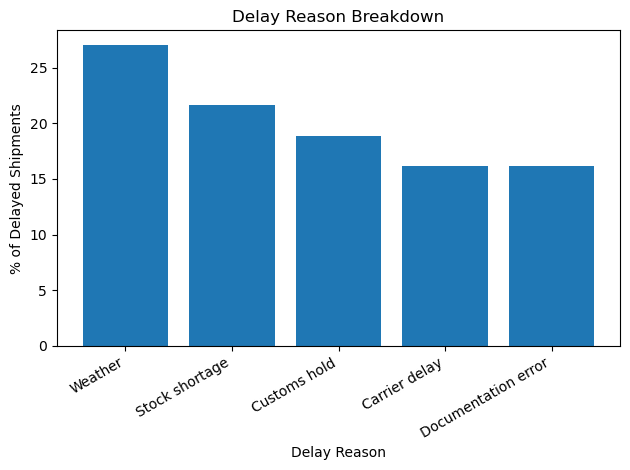

In [7]:
plt.bar(delay_reason_table.index, delay_reason_table['pct_of_delayed'])
plt.title('Delay Reason Breakdown')
plt.xlabel('Delay Reason')
plt.ylabel('% of Delayed Shipments')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

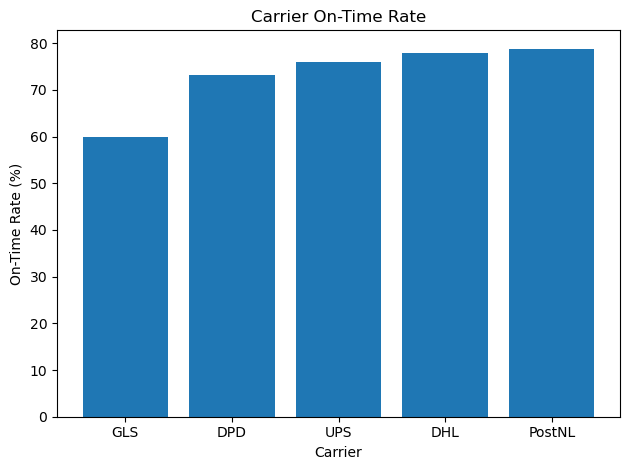

In [8]:
plt.bar(carrier_table.index, carrier_table['on_time_rate'])
plt.title('Carrier On-Time Rate')
plt.xlabel('Carrier')
plt.ylabel('On-Time Rate (%)')
plt.tight_layout()
plt.show()

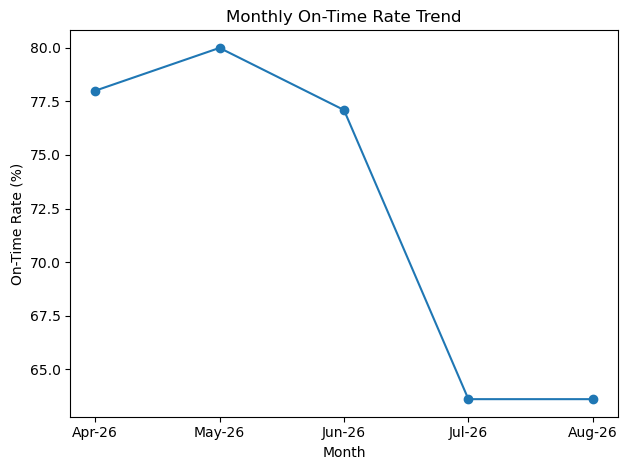

In [9]:
plt.plot(monthly_table.index, monthly_table['on_time_rate'], marker='o')
plt.title('Monthly On-Time Rate Trend')
plt.xlabel('Month')
plt.ylabel('On-Time Rate (%)')
plt.tight_layout()
plt.show()

## Key findings

- Overall on-time rate is **73.6%** across 140 shipments (€126,797 total value).
- **Weather** is the single biggest delay driver (27% of delayed shipments), followed by stock shortages (21.6%).
- **GLS is the weak carrier**, on time only 60% of the time vs. 78.8% for PostNL.
- On-time rate is trending **down**, from ~78-80% in Apr/May-26 to 63.6% in Jul/Aug-26.
- Recommendation: a shared delay log visible to warehouse, carriers, and customer-facing staff, plus a direct performance review with GLS.